In [1]:
import cv2
import numpy as np
import yaml
import os

In [4]:


# === 1. Define folder paths ===
ROOT_DIR = 'Dataset/images0'
CAMERA_YAML = os.path.join(ROOT_DIR, 'camera_intrinsics.yml')
RGB_DIR = os.path.join(ROOT_DIR, 'train', 'rgb')

# === 2. Load camera intrinsics ===
if not intrinsics_path.exists():
    raise FileNotFoundError(f"Camera intrinsics file not found: {intrinsics_path}")

fs = cv2.FileStorage(str(intrinsics_path), cv2.FILE_STORAGE_READ)
K = fs.getNode("K").mat()
D = fs.getNode("D").mat()
xi = fs.getNode("xi").real()
fs.release()

print("Loaded Camera Intrinsics:")
print("K = \n", K)
print("D = \n", D)
print("xi = ", xi)

# === 3. Load images ===
# Adjust filenames to match yours exactly (case-sensitive!)
image_files = {
    'front': os.path.join(RGB_DIR, 'front', 'image.png'),
    'rear':  os.path.join(RGB_DIR, 'rear', 'image.png'),
    'left':  os.path.join(RGB_DIR, 'left', 'image.png'),
    'right': os.path.join(RGB_DIR, 'right', 'image.png'),
}

images = {}
# Try loading with 'image.png' filenames
for name, path in image_files.items():
    if os.path.exists(path):
        img = cv2.imread(path)
        if img is not None:
            images[name] = img
        else:
            print(f"WARNING: Could not load image: {path}")
    else:
        print(f"WARNING: File does not exist: {path}")

# If no images loaded, try with '0.png' filenames
if not images:
    for name in ['front', 'rear', 'left', 'right']:
        img_path = os.path.join(RGB_DIR, name, '0.png')
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            if img is not None:
                images[name] = img
            else:
                print(f"WARNING: Could not load image: {img_path}")
        else:
            print(f"WARNING: File does not exist: {img_path}")

if not images:
    raise RuntimeError("No images were loaded. Please check your file paths and data.")
# === 4. Undistort images ===
undistorted_images = {}
for name, img in images.items():
    h, w = img.shape[:2]
    undistorted = cv2.omnidir.undistortImage(
        img, K, D, xi,
        flags=cv2.omnidir.RECTIFY_PERSPECTIVE,
        Knew=K,
        new_size=(w, h)
    )
    undistorted_images[name] = undistorted

# === 5. Setup BEV canvas ===
BEV_WIDTH, BEV_HEIGHT = 1000, 1000
bev_canvas = np.zeros((BEV_HEIGHT, BEV_WIDTH, 3), dtype=np.uint8)

# === 6. Example transforms (approximate, tweak as needed) ===
# These translate each view to a quadrant of the canvas.
# For production, use true extrinsic calibration!
transforms = {
    'front': np.float32([[1, 0, BEV_WIDTH // 4],
                         [0, 1, 0]]),
    'rear':  np.float32([[1, 0, BEV_WIDTH // 4],
                         [0, 1, BEV_HEIGHT // 2]]),
    'left':  np.float32([[1, 0, 0],
                         [0, 1, BEV_HEIGHT // 4]]),
    'right': np.float32([[1, 0, BEV_WIDTH // 2],
                         [0, 1, BEV_HEIGHT // 4]])
}

# === 7. Warp & blend ===
for name, img in undistorted_images.items():
    warped = cv2.warpAffine(
        img,
        transforms[name],
        (BEV_WIDTH, BEV_HEIGHT)
    )
    mask = (warped > 0).astype(np.uint8)
    bev_canvas = cv2.addWeighted(bev_canvas, 0.5, warped, 0.5, 0)

# === 8. Show result ===
cv2.imshow('Fused BEV', bev_canvas)
cv2.waitKey(0)
cv2.destroyAllWindows()

# --- Read and display a proper image and its camera configuration from local files ---
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

# Set up paths
base_dir = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0/train").resolve()
cfg_dir = base_dir / "cameraconfig"
rgb_dir = base_dir / "rgb"
camera_names = ["front", "rear", "left", "right"]

# Find a valid frame
config_files = sorted([f for f in cfg_dir.glob("*.txt")])
frame_ids = [f.stem for f in config_files if f.stem.isdigit()]
valid_frame_ids = []
for fid in frame_ids:
    all_exist = True
    for cam in camera_names:
        rgb_path = rgb_dir / cam / f"{fid}.png"
        if not rgb_path.exists():
            all_exist = False
            break
    if all_exist:
        valid_frame_ids.append(fid)

# Pick the first valid frame and camera
frame_id = valid_frame_ids[0]
cam = camera_names[0]
img_path = rgb_dir / cam / f"{frame_id}.png"
img = cv2.imread(str(img_path))

# Read camera config for this frame
config_path = cfg_dir / f"{frame_id}.txt"
with open(config_path, 'r') as f:
    config_lines = f.readlines()

print(f"Image path: {img_path}")
print(f"Camera config for frame {frame_id}:")
for line in config_lines:
    print(line.strip())

plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"{cam} image for frame {frame_id}")
plt.axis('off')
plt.show()

# --- Read and display a specific image, its camera config, and intrinsics ---
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import yaml

# Paths for the specific files
img_path = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0/train/rgb/front/0.png")
cfg_path = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0/train/cameraconfig/0.txt")
intr_path = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0/camera_intrinsics.yml")

# Read and display the image
img = cv2.imread(str(img_path))
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("front image for frame 0")
plt.axis('off')
plt.show()

# Read and print camera config
print(f"Camera config for frame 0:")
with open(cfg_path, 'r') as f:
    for line in f:
        print(line.strip())

# Read and print camera intrinsics
print("\nCamera intrinsics (from camera_intrinsics.yml):")
with open(intr_path, 'r') as f:
    intr_data = yaml.safe_load(f)
    print(intr_data)


NameError: name 'os' is not defined

In [38]:
# Simple: Iteratively read each image in the path and its config data
from pathlib import Path
import cv2

rgb_dir = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0/train/rgb/front")
cfg_dir = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0/train/cameraconfig")

# Get all image files in the rgb/front directory
image_files = sorted(rgb_dir.glob("*.png"))

for img_path in image_files:
    frame_id = img_path.stem
    cfg_path = cfg_dir / f"{frame_id}.txt"
    print(f"Image: {img_path}")
    if cfg_path.exists():
        print(f"Config: {cfg_path}")
        with open(cfg_path, 'r') as f:
            print(f.read())
    else:
        print("Config file not found!")
    print("-"*40)
    # Optionally, display the image (uncomment below)
    # img = cv2.imread(str(img_path))
    # cv2.imshow('Image', img)
    # cv2.waitKey(0)
    # cv2.destroyAllWindows()

Image: D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\rgb\front\0.png
Config: D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\cameraconfig\0.txt
cam_name, posi_x, posi_y, posi_z, rot_x, rot_y, rot_z
Main Camera-front, 16.827, 0.9156191, -48.8, 26, 270, 180
Main Camera-right, 18.66, 1.310619, -47.785, 1.335966E-06, -1.140713E-15, -9.784387E-08
Main Camera-left, 18.647, 1.309619, -49.824, -1.335966E-06, 180, 9.784387E-08
Main Camera-rear, 21.701, 1.253619, -48.668, 2.999997, 90, 180
BEVCamera, 19.3055, 40.13262, -48.8, 90, 270, 0

----------------------------------------
Image: D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\rgb\front\1.png
Config: D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\cameraconfig\1.txt
cam_name, posi_x, posi_y, posi_z, rot_x, rot_y, rot_z
Main Camera-front, 16.73686, 0.9183073, -48.79994, 25.95748, 269.999, 179.9976
Main Camera-right, 18.57015, 1.311909, -47.78492, 0.002152795, -1.445925E-05, 359.9575
Main Camera-left, 18.55715, 1.310995, -49

Image: D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\rgb\front\0.png


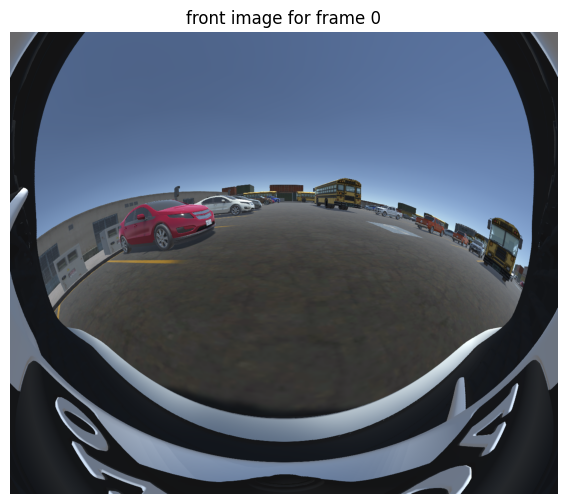

Config: D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\cameraconfig\0.txt
cam_name, posi_x, posi_y, posi_z, rot_x, rot_y, rot_z
Main Camera-front, 16.827, 0.9156191, -48.8, 26, 270, 180
Main Camera-right, 18.66, 1.310619, -47.785, 1.335966E-06, -1.140713E-15, -9.784387E-08
Main Camera-left, 18.647, 1.309619, -49.824, -1.335966E-06, 180, 9.784387E-08
Main Camera-rear, 21.701, 1.253619, -48.668, 2.999997, 90, 180
BEVCamera, 19.3055, 40.13262, -48.8, 90, 270, 0



In [41]:

# Read and print a single image and its config (frame 0, front camera)
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

img_path = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0/train/rgb/front/0.png")
cfg_path = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0/train/cameraconfig/0.txt")

print(f"Image: {img_path}")
img = cv2.imread(str(img_path))
plt.figure(figsize=(8,6))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("front image for frame 0")
plt.axis('off')
plt.show()

print(f"Config: {cfg_path}")
with open(cfg_path, 'r') as f:
    print(f.read())

In [7]:
import cv2
import numpy as np
from pathlib import Path

# === [1] Define dataset root ===
root = Path(r"D:\Mtech\Disseration\BEV_Adas\Dataset\images0")

intrinsics_file = root / "camera_intrinsics.yml"
config_file = root / "train" / "cameraconfig" / "0.txt"
rgb_dir = root / "train" / "rgb"

camera_names = ["front", "rear", "left", "right"]

print(f"\n[INFO] Using dataset root: {root}")

# === [2] Check files ===
for path in [intrinsics_file, config_file]:
    print(f"  {path} --> {'OK' if path.exists() else 'MISSING'}")
    assert path.exists(), f"❌ File not found: {path}"

for name in camera_names:
    img_path = rgb_dir / name / "0.png"
    print(f"  {img_path} --> {'OK' if img_path.exists() else 'MISSING'}")
    assert img_path.exists(), f"❌ Image missing: {img_path}"

# === [3] Load intrinsics properly ===
fs = cv2.FileStorage(str(intrinsics_file), cv2.FILE_STORAGE_READ)

K = fs.getNode("K").mat()
D = fs.getNode("D").mat()
xi_node = fs.getNode("xi")

# Extract xi robustly
if xi_node.isSeq():
    xi = xi_node.mat()[0, 0]
else:
    xi = xi_node.real()

# Wrap as OpenCV-compatible 1x1 matrix
xi = np.array([[np.float64(xi)]])
fs.release()

print(f"\n[INFO] Loaded intrinsics:")
print(f"K =\n{K}")
print(f"D = {D}")
print(f"xi = {xi} (shape: {xi.shape}, dtype: {xi.dtype})")

# === [4] Load extrinsics ===
def parse_config(path):
    extrinsics = {}
    with open(path) as f:
        lines = [l.strip() for l in f if l.strip() and not l.startswith('#')]
        for line in lines[1:]:
            parts = line.split(',')
            name = parts[0].split('-')[-1].lower()
            pos = [float(parts[1]), float(parts[2]), float(parts[3])]
            rot = [float(parts[4]), float(parts[5]), float(parts[6])]
            extrinsics[name] = {'pos': np.array(pos), 'rot': np.array(rot)}
    return extrinsics

extrinsics = parse_config(config_file)
print(f"\n[INFO] Loaded extrinsics: {list(extrinsics.keys())}")

# === [5] Load & undistort images ===
undistorted = {}
for name in camera_names:
    img_path = rgb_dir / name / "0.png"
    img = cv2.imread(str(img_path))
    if img is None:
        raise RuntimeError(f"❌ Failed to load: {img_path}")

    h, w = img.shape[:2]
    undist = cv2.omnidir.undistortImage(
        img, K, D, xi,
        flags=cv2.omnidir.RECTIFY_PERSPECTIVE,
        Knew=K,
        new_size=(w, h)
    )
    undistorted[name] = undist
    print(f"[INFO] Undistorted: {name}")

# === [6] Compute BEV homographies (ground plane Z=0) ===
def euler_to_R(roll, pitch, yaw):
    rx, ry, rz = np.deg2rad([roll, pitch, yaw])
    Rx = np.array([[1, 0, 0],
                   [0, np.cos(rx), -np.sin(rx)],
                   [0, np.sin(rx), np.cos(rx)]])
    Ry = np.array([[np.cos(ry), 0, np.sin(ry)],
                   [0, 1, 0],
                   [-np.sin(ry), 0, np.cos(ry)]])
    Rz = np.array([[np.cos(rz), -np.sin(rz), 0],
                   [np.sin(rz), np.cos(rz), 0],
                   [0, 0, 1]])
    return Rz @ Ry @ Rx

homographies = {}
for name in undistorted:
    ext = extrinsics[name]
    R = euler_to_R(*ext['rot'])
    t = ext['pos'].reshape(3, 1)

    # Camera projection matrix P = K [R|t]
    Rt = np.hstack((R, t))
    P = K @ Rt

    # For ground plane Z=0: drop 3rd column
    H = P[:, [0, 1, 3]]

    # Invert: maps BEV plane to image
    homographies[name] = np.linalg.inv(H)
    print(f"[INFO] Homography OK: {name}")

# === [7] Warp and blend ===
bev_size = (1200, 1200)
bev = np.zeros((*bev_size, 3), dtype=np.uint8)

for name, img in undistorted.items():
    H = homographies[name]
    warped = cv2.warpPerspective(img, H, bev_size, borderMode=cv2.BORDER_TRANSPARENT)
    mask = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY) > 0
    bev[mask] = warped[mask]
    print(f"[INFO] Warped & fused: {name}")

# === [8] Show and save ===
output_file = root / "bev_output_corrected.png"
cv2.imwrite(str(output_file), bev)
print(f"\n✅ [INFO] Saved final BEV: {output_file}")

cv2.imshow("Bird Eye View Fusion", bev)
cv2.waitKey(0)
cv2.destroyAllWindows()



[INFO] Using dataset root: D:\Mtech\Disseration\BEV_Adas\Dataset\images0
  D:\Mtech\Disseration\BEV_Adas\Dataset\images0\camera_intrinsics.yml --> OK
  D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\cameraconfig\0.txt --> OK
  D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\rgb\front\0.png --> OK
  D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\rgb\rear\0.png --> OK
  D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\rgb\left\0.png --> OK
  D:\Mtech\Disseration\BEV_Adas\Dataset\images0\train\rgb\right\0.png --> OK

[INFO] Loaded intrinsics:
K =
[[659.95654055  -2.88485084 634.6329612 ]
 [  0.         625.10325209 544.74330559]
 [  0.           0.           1.        ]]
D = [[-0.29002694  0.11089496 -0.00032225  0.00291106]]
xi = [[1.79769313e+308]] (shape: (1, 1), dtype: float64)

[INFO] Loaded extrinsics: ['front', 'right', 'left', 'rear', 'bevcamera']


AttributeError: module 'cv2' has no attribute 'omnidir'

In [8]:
import cv2
import numpy as np
from pathlib import Path

# === [1] Setup paths ===
root = Path(r"D:\Mtech\Disseration\BEV_Adas\Dataset\images0")
rgb_dir = root / "train/rgb"
camera_names = ["front", "rear", "left", "right"]

# === [2] Load and undistort images ===
undistorted = {}
for name in camera_names:
    img_path = rgb_dir / name / "0.png"
    img = cv2.imread(str(img_path))
    assert img is not None, f"Image not found: {img_path}"
    undistorted[name] = img  # We'll use raw images for manual points first

# === [3] === Manual control points (EXAMPLE!)
# In real usage, pick these using cv2.setMouseCallback or cv2.selectROI for each image.
# Below are FAKE sample points -- replace with your real measured corner points!

# Example for front camera:
# src: 4 points in image pixel coordinates (corners on ground)
# dst: 4 points in BEV plane (meters or pixels in output)

# Note: these are placeholder values — you must pick yours!

control_points = {
    "front": {
        "src": np.array([[620, 700], [800, 700], [900, 800], [500, 800]], dtype=np.float32),
        "dst": np.array([[500, 400], [700, 400], [700, 600], [500, 600]], dtype=np.float32)
    },
    "rear": {
        "src": np.array([[600, 500], [850, 500], [900, 700], [500, 700]], dtype=np.float32),
        "dst": np.array([[500, 800], [700, 800], [700, 1000], [500, 1000]], dtype=np.float32)
    },
    "left": {
        "src": np.array([[400, 600], [700, 600], [700, 800], [400, 800]], dtype=np.float32),
        "dst": np.array([[300, 600], [500, 600], [500, 800], [300, 800]], dtype=np.float32)
    },
    "right": {
        "src": np.array([[600, 600], [900, 600], [900, 800], [600, 800]], dtype=np.float32),
        "dst": np.array([[700, 600], [900, 600], [900, 800], [700, 800]], dtype=np.float32)
    }
}

# === [4] === Compute homographies
homographies = {}
for name in camera_names:
    src = control_points[name]["src"]
    dst = control_points[name]["dst"]
    H, _ = cv2.findHomography(src, dst)
    homographies[name] = H
    print(f"[INFO] Homography for {name}:\n{H}")

# === [5] === Warp & blend
bev_w, bev_h = 1200, 1200
bev = np.zeros((bev_h, bev_w, 3), dtype=np.uint8)

for name in camera_names:
    img = undistorted[name]
    H = homographies[name]
    warped = cv2.warpPerspective(img, H, (bev_w, bev_h))
    mask = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY) > 0
    bev[mask] = warped[mask]
    print(f"[INFO] Warped & blended: {name}")

# === [6] === Save & show
out_file = root / "bev_manual_homography.png"
cv2.imwrite(str(out_file), bev)
print(f"\n✅ Saved BEV: {out_file}")

cv2.imshow("Bird Eye View Fusion", bev)
cv2.waitKey(0)
cv2.destroyAllWindows()


[INFO] Homography for front:
[[-1.47058824e-01 -9.85294118e-01  7.14705882e+02]
 [-8.03574392e-17 -1.23529412e+00  8.11764706e+02]
 [-1.43422764e-19 -1.61764706e-03  1.00000000e+00]]
[INFO] Homography for rear:
[[-1.60000000e+00 -3.80000000e+00  1.86000000e+03]
 [-5.94679887e-16 -8.00000000e+00  2.40000000e+03]
 [-6.58222341e-19 -6.00000000e-03  1.00000000e+00]]
[INFO] Homography for left:
[[ 6.66666667e-01  0.00000000e+00  3.33333333e+01]
 [ 0.00000000e+00  1.00000000e+00 -3.93822758e-13]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[INFO] Homography for right:
[[ 6.66666667e-01  0.00000000e+00  3.00000000e+02]
 [ 0.00000000e+00  1.00000000e+00 -3.93822758e-13]
 [ 0.00000000e+00  0.00000000e+00  1.00000000e+00]]
[INFO] Warped & blended: front
[INFO] Warped & blended: rear
[INFO] Warped & blended: left
[INFO] Warped & blended: right

✅ Saved BEV: D:\Mtech\Disseration\BEV_Adas\Dataset\images0\bev_manual_homography.png

✅ Saved BEV: D:\Mtech\Disseration\BEV_Adas\Dataset\images0\be

In [1]:
# --- 1) Imports & Paths ---
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

%matplotlib inline

root = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0").resolve()

intrinsics_file = root / "camera_intrinsics.yml"
rgb_dir = root / "train/rgb"
camera_names = ["front", "rear", "left", "right"]
frame_id = "0"  # use frame 0 for test

print(f"[INFO] Root: {root}")


[INFO] Root: D:\Mtech\Disseration\BEV_Adas\Dataset\images0


In [2]:
# --- 2) Load images ---
imgs = {}
for cam in camera_names:
    path = rgb_dir / cam / f"{frame_id}.png"
    img = cv2.imread(str(path))
    if img is None:
        print(f"[WARN] Not found: {path}")
    else:
        imgs[cam] = img
print(f"[INFO] Loaded: {list(imgs.keys())}")


[INFO] Loaded: ['front', 'rear', 'left', 'right']


In [3]:
# --- 3) Click helper to get SRC points interactively ---

clicked_points = []

def click_event(event, x, y, flags, param):
    global clicked_points
    if event == cv2.EVENT_LBUTTONDOWN:
        clicked_points.append([x, y])
        print(f"Point: {x}, {y}")

# Example: click 4 points for FRONT camera
cam_name = "front"
img = imgs[cam_name].copy()
cv2.namedWindow("Click 4 SRC points")
cv2.setMouseCallback("Click 4 SRC points", click_event)

while True:
    tmp = img.copy()
    for p in clicked_points:
        cv2.circle(tmp, tuple(p), 5, (0,0,255), -1)
    cv2.imshow("Click 4 SRC points", tmp)
    if cv2.waitKey(1) & 0xFF == ord('q') or len(clicked_points) == 4:
        break

cv2.destroyAllWindows()

print(f"SRC points for {cam_name}:", clicked_points)


Point: 193, 98
Point: 1001, 82
Point: 1001, 82
Point: 1018, 769
Point: 1018, 769
Point: 258, 773
SRC points for front: [[193, 98], [1001, 82], [1018, 769], [258, 773]]
Point: 258, 773
SRC points for front: [[193, 98], [1001, 82], [1018, 769], [258, 773]]


In [4]:
# --- 4) Define DST points for BEV ---
# Example: front camera maps to a rectangle in BEV canvas
# You can tweak size and position as needed.

bev_size = (800, 800)  # width, height

# Example destination: front occupies top-center
dst_points = np.array([
    [300, 400],  # left-near
    [500, 400],  # right-near
    [500, 100],  # right-far
    [300, 100]   # left-far
], dtype=np.float32)

print("DST points:", dst_points)


DST points: [[300. 400.]
 [500. 400.]
 [500. 100.]
 [300. 100.]]


In [5]:
# --- 6) Repeat for other cameras ---
# Do the same: click 4 SRC points per camera.
# Define DST so they connect seamlessly.

# Example: left camera covers left side
# Example: rear covers bottom, etc.

# Then blend them all:

bev = np.zeros((bev_size[1], bev_size[0], 3), dtype=np.uint8)

# For demo, only front:
bev[warped > 0] = warped[warped > 0]

plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(bev, cv2.COLOR_BGR2RGB))
plt.title("Current BEV fusion")
plt.show()


NameError: name 'warped' is not defined

[INFO] Root: D:\Mtech\Disseration\BEV_Adas\Dataset\images0
[INFO] Loaded: ['front', 'rear', 'left', 'right']
[front] Point: (161, 72)
[front] Point: (161, 72)
[front] Point: (1069, 58)
[front] Point: (1069, 58)
[front] Point: (1089, 648)
[front] Point: (1089, 648)
[front] Point: (142, 656)
[front] Point: (142, 656)
[rear] Point: (124, 78)
[rear] Point: (124, 78)
[rear] Point: (1093, 96)
[rear] Point: (1093, 96)
[rear] Point: (1132, 689)
[rear] Point: (1132, 689)
[rear] Point: (99, 647)
[rear] Point: (99, 647)
[left] Point: (131, 105)
[left] Point: (131, 105)
[left] Point: (1160, 104)
[left] Point: (1160, 104)
[left] Point: (1163, 645)
[left] Point: (1163, 645)
[left] Point: (140, 616)
[left] Point: (140, 616)
[right] Point: (26, 77)
[right] Point: (26, 77)
[right] Point: (1127, 131)
[right] Point: (1127, 131)
[right] Point: (1119, 664)
[right] Point: (1119, 664)
[right] Point: (69, 698)

✅ All SRC points collected:
{'front': array([[ 161.,   72.],
       [1069.,   58.],
       [1089., 

c:\Users\uif02672\.conda\envs\mtechproj\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


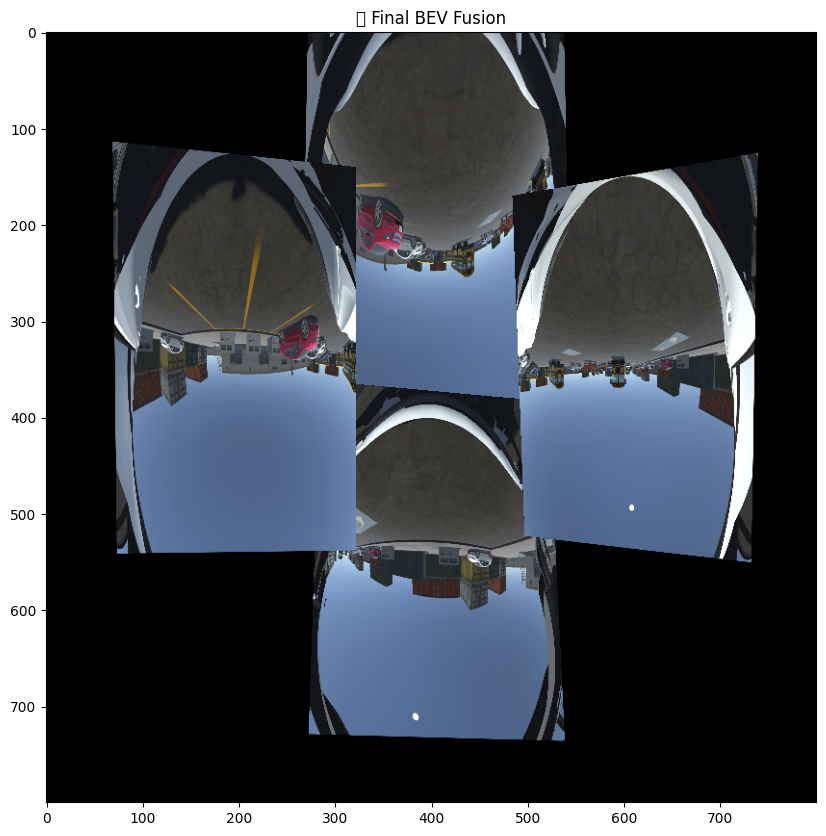

In [14]:
# === 1) Imports & Paths ===
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

root = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0").resolve()
rgb_dir = root / "train/rgb"
camera_names = ["front", "rear", "left", "right"]
frame_id = "0"

print(f"[INFO] Root: {root}")

# === 2) Load images ===
imgs = {}
for cam in camera_names:
    path = rgb_dir / cam / f"{frame_id}.png"
    img = cv2.imread(str(path))
    if img is None:
        print(f"[WARN] Not found: {path}")
    else:
        imgs[cam] = img
print(f"[INFO] Loaded: {list(imgs.keys())}")

# === 3) Robust OpenCV click helper ===
def get_four_points(image, cam_name):
    points = []
    def click(event, x, y, flags, param):
        if event == cv2.EVENT_LBUTTONDOWN and len(points) < 4:
            points.append([x, y])
            print(f"[{cam_name}] Point: ({x}, {y})")

    window_name = f"Click 4 points for {cam_name}"
    cv2.namedWindow(window_name)
    cv2.setMouseCallback(window_name, click)

    while True:
        clone = image.copy()
        for p in points:
            cv2.circle(clone, tuple(p), 5, (0, 0, 255), -1)
        cv2.imshow(window_name, clone)
        if cv2.waitKey(1) & 0xFF == ord('q') or len(points) == 4:
            break

    cv2.destroyWindow(window_name)
    return np.array(points, dtype=np.float32)

# === 4) Click SRC for all cameras ===
src_points_all = {}
for cam in camera_names:
    src_points_all[cam] = get_four_points(imgs[cam], cam)

print(f"\n✅ All SRC points collected:\n{src_points_all}")

# === 5) Define DST for each cam ===
bev_size = (800, 800)
dst_points_all = {
    'front': np.array([[300, 400], [500, 400], [500, 100], [300, 100]], np.float32),
    'rear' : np.array([[300, 700], [500, 700], [500, 500], [300, 500]], np.float32),
    'left' : np.array([[100, 500], [300, 500], [300, 300], [100, 300]], np.float32),
    'right': np.array([[500, 500], [700, 500], [700, 300], [500, 300]], np.float32)
}

# === 6) Warp & blend ===
bev = np.zeros((bev_size[1], bev_size[0], 3), dtype=np.uint8)

for cam in camera_names:
    src = src_points_all[cam]
    dst = dst_points_all[cam]
    H, _ = cv2.findHomography(src, dst)
    warped = cv2.warpPerspective(imgs[cam], H, bev_size)
    mask = (warped > 0).any(axis=2)
    bev[mask] = warped[mask]
    print(f"[INFO] Warped & added: {cam}")

# === 7) Show final BEV ===
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(bev, cv2.COLOR_BGR2RGB))
plt.title("✅ Final BEV Fusion")
plt.show()


[INFO] Loaded & undistorted: ['front', 'rear', 'left', 'right']
[INFO] front done: warp + rotate 0° + blend.
[INFO] rear done: warp + rotate 180° + blend.
[INFO] left done: warp + rotate 90° + blend.
[INFO] right done: warp + rotate -90° + blend.


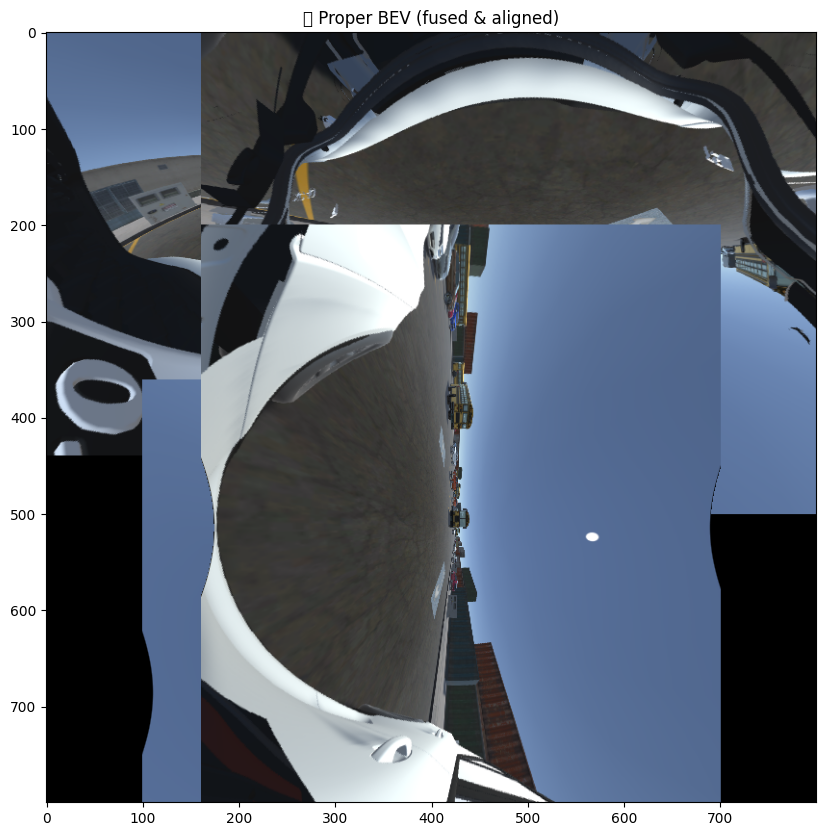

In [ ]:
# ========================================
# ✅ 1) Imports & Backend
# ========================================
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# %matplotlib qt  # if you want interactive point picking

root = Path(r"D:/Mtech/Disseration/BEV_Adas/Dataset/images0").resolve()
rgb_dir = root / "train/rgb"
camera_names = ["front", "rear", "left", "right"]
frame_id = "0"

# Example intrinsics for fisheye (adjust as needed)
K = np.array([
    [659.95, 0, 634.63],
    [0.0, 625.10, 544.74],
    [0.0, 0.0, 1.0]
])
D = np.array([-0.29, 0.11, -0.00032, 0.00291])

bev_size = (800, 800)

# ========================================
# ✅ 2) Load & Undistort
# ========================================
imgs = {}
undistorted = {}

for cam in camera_names:
    path = rgb_dir / cam / f"{frame_id}.png"
    img = cv2.imread(str(path))
    if img is not None:
        imgs[cam] = img
        h, w = img.shape[:2]
        new_K = cv2.fisheye.estimateNewCameraMatrixForUndistortRectify(K, D, (w, h), np.eye(3))
        map1, map2 = cv2.fisheye.initUndistortRectifyMap(K, D, np.eye(3), new_K, (w, h), cv2.CV_16SC2)
        u_img = cv2.remap(img, map1, map2, interpolation=cv2.INTER_LINEAR)
        undistorted[cam] = u_img
    else:
        print(f"[WARN] Missing: {path}")

print(f"[INFO] Loaded & undistorted: {list(undistorted.keys())}")

# ========================================
# ✅ 3) Provide SRC and DST points
# ========================================
# For quick testing, approximate SRCs covering ground area
src_points_all = {
    "front": np.array([[600, 800], [1000, 800], [1000, 400], [600, 400]], np.float32),
    "rear" : np.array([[600, 800], [1000, 800], [1000, 400], [600, 400]], np.float32),
    "left" : np.array([[600, 800], [1000, 800], [1000, 400], [600, 400]], np.float32),
    "right": np.array([[600, 800], [1000, 800], [1000, 400], [600, 400]], np.float32),
}

# Define DST rectangles (in BEV) for each camera
dst_points_all = {
    "front": np.array([[300, 300], [500, 300], [500, 100], [300, 100]], np.float32),
    "rear" : np.array([[300, 700], [500, 700], [500, 500], [300, 500]], np.float32),
    "left" : np.array([[100, 500], [300, 500], [300, 300], [100, 300]], np.float32),
    "right": np.array([[500, 500], [700, 500], [700, 300], [500, 300]], np.float32)
}

# Rotations (to make all views align properly)
rotations = {
    "front": 0,
    "rear": 180,
    "left": 90,
    "right": -90
}

# ========================================
# ✅ 4) Warp, Rotate, and Fuse
# ========================================
bev = np.zeros((bev_size[1], bev_size[0], 3), np.uint8)

for cam in camera_names:
    src = src_points_all[cam]
    dst = dst_points_all[cam]

    H, _ = cv2.findHomography(src, dst)
    warped = cv2.warpPerspective(undistorted[cam], H, bev_size)

    # Rotate to match real-world car coordinate frame
    angle = rotations[cam]
    if angle != 0:
        M = cv2.getRotationMatrix2D((bev_size[0]//2, bev_size[1]//2), angle, 1.0)
        warped = cv2.warpAffine(warped, M, bev_size)

    mask = (warped > 0).any(axis=2)
    bev[mask] = warped[mask]

    print(f"[INFO] {cam} done: warp + rotate {angle}° + blend.")

# ========================================
# ✅ 5) Show result
# ========================================
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(bev, cv2.COLOR_BGR2RGB))
plt.title("✅ Proper BEV (fused & aligned)")
plt.show()

